In [8]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import time
from IPython.display import display
import io
from PIL import Image

In [9]:
from lsb.lsb import LSB
from dct.dct import DCT
from steganogan import SteganoGAN

from utils.utils import calculate_psnr, calculate_ssim, test_max_message_lsb, test_max_message_dct, test_max_message_gan
from utils.utils import create_random_string


In [10]:
secret_message  = 'taka21'

In [11]:
steganoGAN = SteganoGAN.load(path='../steganoGAN/pretrained/dense.steg')
dct_tool = DCT()
lsb_tool = LSB()

In [12]:
# 1. Load and prepare the dataset
image_dir = "data/div2k/val/DIV2K_valid_HR"
image_files = [f for f in sorted(os.listdir(image_dir)) if f.endswith(('.png'))]


In [13]:
# 2. Create a DataFrame to store results
results = []

In [14]:


# 3. Process each image with all three methods
for img_file in tqdm(image_files, desc="Processing Images"):
    # Load original image
    img_path = os.path.join(image_dir, img_file)
    original = cv2.imread(img_path)
    # Get original file size
    original_size = os.path.getsize(img_path)

    # Dictionary to store results for this image
    img_results = {
        'image_name': img_file,
        'original_size': original_size
    }

    # Create temporary storage paths for stego images
    temp_lsb = "temp_lsb.png"
    temp_dct = "temp_dct.png"
    temp_gan = "temp_gan.png"

    # Apply each steganography method and measure metrics
    for method_name, temp_path in [
        ('LSB', temp_lsb),
        ('DCT', temp_dct),
        ('GAN', temp_gan)
    ]:
        try:
            # Time the encoding process
            start_time = time.time()
            if method_name == 'LSB':
                # lsb = LSBSteg(original)
                # stego = lsb.encode_text(secret_message)
                stego = lsb_tool.encode_message(img_path,temp_path,secret_message)
                max_message_cap = test_max_message_lsb(img_path)
            elif method_name == 'DCT':
                stego = dct_tool.encode_image(original,secret_message)
                max_message_cap = test_max_message_dct(img_path)
            else:
                stego = steganoGAN.encode(img_path, temp_path, secret_message)
                max_message_cap = test_max_message_gan(img_path)

            encoding_time = time.time() - start_time

            # Save the stego image temporarily to get file size
            cv2.imwrite(temp_path, stego)
            stego_size = os.path.getsize(temp_path)

            # Calculate PSNR and SSIM
            psnr_value = calculate_psnr(original, stego)
            ssim_value = calculate_ssim(original, stego)

            # Store metrics
            img_results[f'{method_name}_psnr'] = psnr_value
            img_results[f'{method_name}_ssim'] = ssim_value
            img_results[f'{method_name}_size'] = stego_size
            img_results[f'{method_name}_size_ratio'] = stego_size / original_size
            img_results[f'{method_name}_time'] = encoding_time
            img_results[f'{method_name}_max_message_cap'] = max_message_cap

        except Exception as e:
            # Log errors but continue with other methods/images
            print(f"Error processing {img_file} with {method_name}: {e}")
            img_results[f'{method_name}_psnr'] = np.nan
            img_results[f'{method_name}_ssim'] = np.nan
            img_results[f'{method_name}_size'] = np.nan
            img_results[f'{method_name}_size_ratio'] = np.nan
            img_results[f'{method_name}_time'] = np.nan
            img_results[f'{method_name}_max_message_cap'] = max_message_cap

        # Clean up temporary file
        if os.path.exists(temp_path):
            os.remove(temp_path)
    # Add this image's results to the main results list
    results.append(img_results)

Processing Images:   0%|          | 0/100 [00:00<?, ?it/s]

In [15]:
# 4. Convert results to DataFrame
df_results = pd.DataFrame(results)

# 5. Display summary statistics
print("Summary Statistics:")
summary = df_results[['LSB_psnr', 'DCT_psnr', 'GAN_psnr',
                      'LSB_ssim', 'DCT_ssim', 'GAN_ssim',
                      'LSB_size_ratio', 'DCT_size_ratio', 'GAN_size_ratio',
                      'LSB_time', 'DCT_time', 'GAN_time',
                      'LSB_max_message_cap', 'DCT_max_message_cap','GAN_max_message_cap'
                      ]].describe()

Summary Statistics:


In [16]:
display(summary)

,LSB_psnr,DCT_psnr,GAN_psnr,LSB_ssim,DCT_ssim,GAN_ssim,LSB_size_ratio,DCT_size_ratio,GAN_size_ratio,LSB_time,DCT_time,GAN_time,LSB_max_message_cap,DCT_max_message_cap,GAN_max_message_cap
count,100.000000,100.000000,100.000000,1.000000e+02,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02,100.000000,1.000000e+02
mean,102.481908,37.012366,37.834152,1.000000e+00,0.967231,0.943443,1.101094,1.062805,1.288434,1.676664,1.053470,4.504205,1.063136e+06,5524.910000,1.417514e+06
std,0.717677,3.809378,1.858366,3.173013e-09,0.017542,0.040268,0.046663,0.056940,0.493167,0.356270,0.140670,1.506404,1.123384e+05,586.618199,1.497845e+05
min,100.930825,27.622646,31.854192,1.000000e+00,0.857536,0.686282,1.008783,0.940920,1.027504,0.818019,0.627672,2.503765,6.242400e+05,3251.000000,8.323200e+05
25%,102.041409,34.015409,36.809784,1.000000e+00,0.959648,0.939407,1.073159,1.028596,1.144346,1.456243,0.988940,3.973753,1.037340e+06,5386.000000,1.383120e+06
50%,102.433556,37.109804,38.301509,1.000000e+00,0.971398,0.953921,1.088885,1.057126,1.205454,1.672154,1.008973,4.090765,1.037340e+06,5386.000000,1.383120e+06
75%,102.874154,39.458475,39.021640,1.000000e+00,0.976862,0.965345,1.120263,1.088064,1.255409,1.858711,1.098689,4.542208,1.048815e+06,5458.000000,1.398420e+06
max,104.181003,47.170049,40.670505,1.000000e+00,0.993070,0.981417,1.273835,1.267600,5.652466,2.979921,1.710797,16.873160,1.560600e+06,8128.000000,2.080800e+06


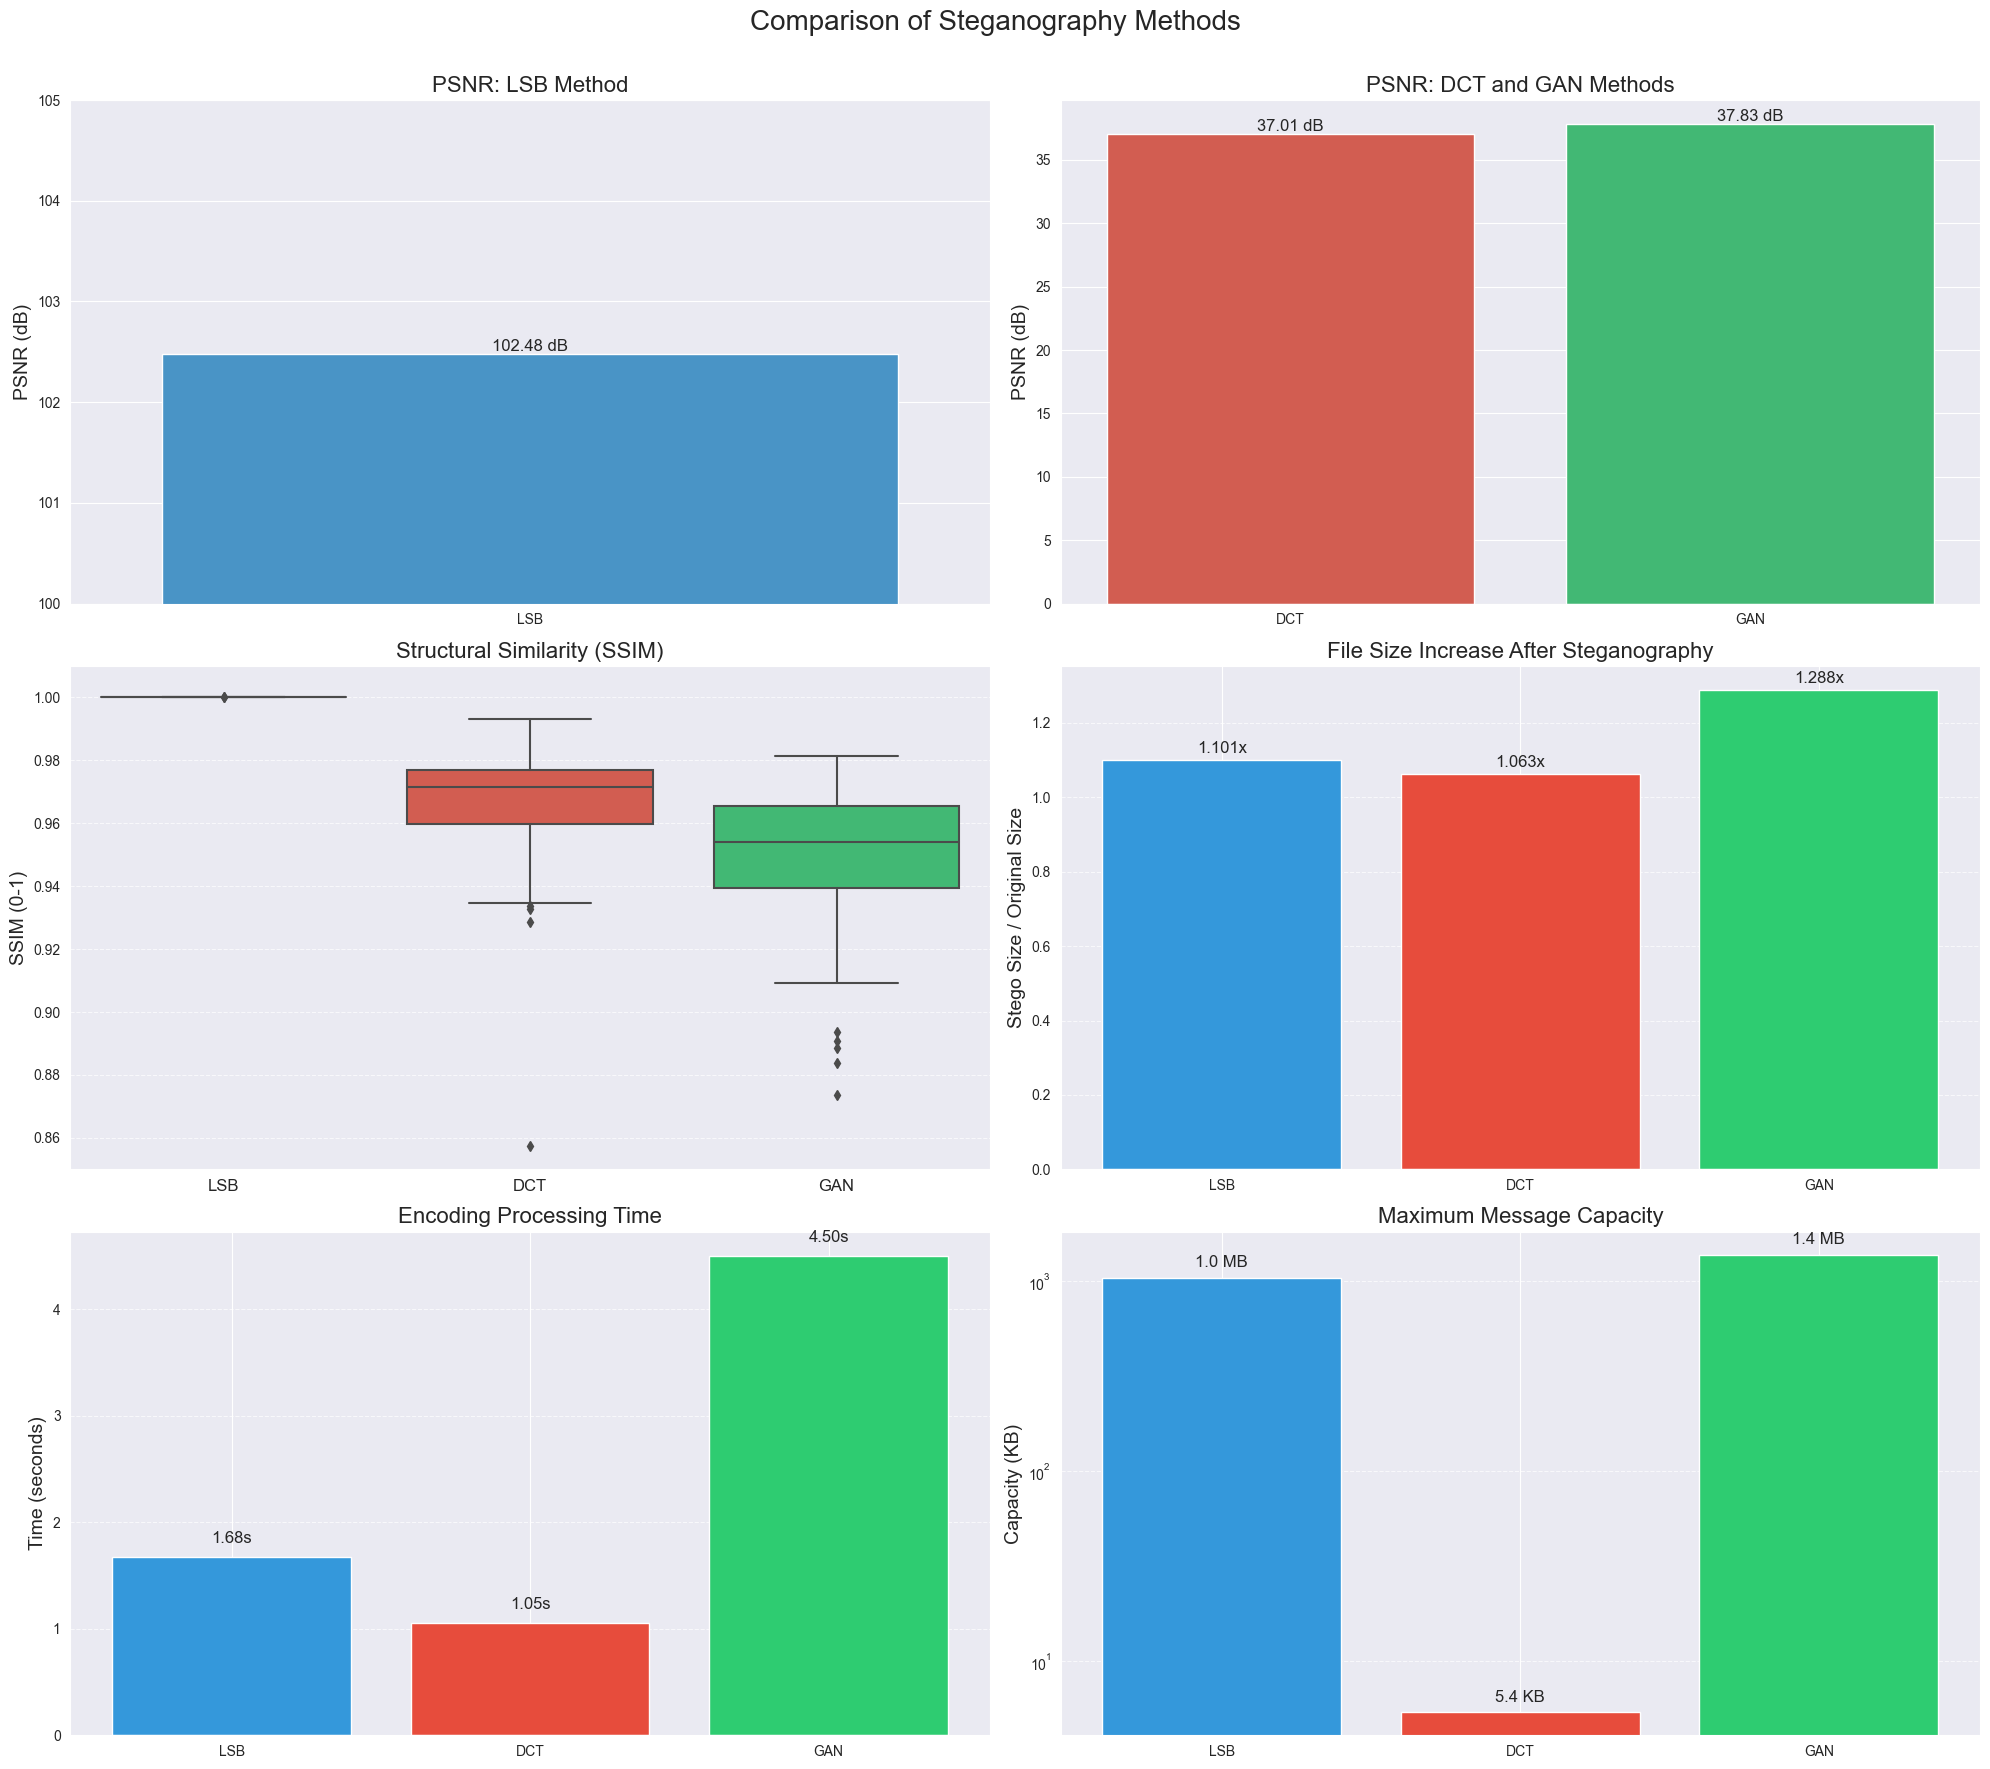

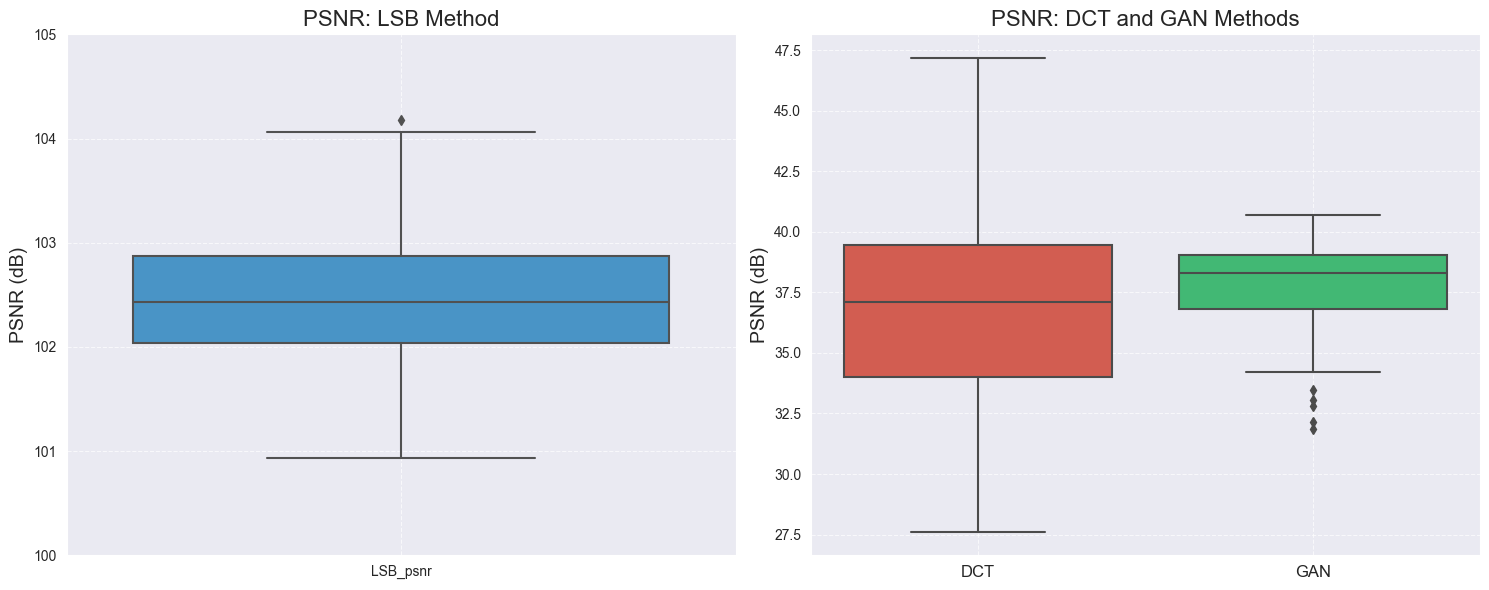

In [17]:
# 6. Visualize the results

# Set a consistent color palette for all plots
method_colors = {'LSB': '#3498db', 'DCT': '#e74c3c', 'GAN': '#2ecc71'}

# Create a figure with 3x2 subplots for all metrics
fig = plt.figure(figsize=(20, 18))
gs = plt.GridSpec(3, 2, figure=fig)

# 1. PSNR Comparison (Split into two plots due to scale differences)
ax1 = fig.add_subplot(gs[0, 0])
sns.barplot(x=['LSB'], y=[df_results['LSB_psnr'].mean()], palette=[method_colors['LSB']], ax=ax1)
ax1.set_title('PSNR: LSB Method', fontsize=16)
ax1.set_ylabel('PSNR (dB)', fontsize=14)
ax1.set_ylim(100, 105)  # Set appropriate range for LSB
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f dB', fontsize=12)

ax2 = fig.add_subplot(gs[0, 1])
sns.barplot(x=['DCT', 'GAN'],
            y=[df_results['DCT_psnr'].mean(), df_results['GAN_psnr'].mean()],
            palette=[method_colors['DCT'], method_colors['GAN']], ax=ax2)
ax2.set_title('PSNR: DCT and GAN Methods', fontsize=16)
ax2.set_ylabel('PSNR (dB)', fontsize=14)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f dB', fontsize=12)

# 2. SSIM Comparison
ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(data=df_results[['LSB_ssim', 'DCT_ssim', 'GAN_ssim']],
            palette=[method_colors['LSB'], method_colors['DCT'], method_colors['GAN']], ax=ax3)
ax3.set_title('Structural Similarity (SSIM)', fontsize=16)
ax3.set_ylabel('SSIM (0-1)', fontsize=14)
ax3.set_ylim(0.85, 1.01)  # Focus on the relevant range
ax3.set_xticklabels(['LSB', 'DCT', 'GAN'], fontsize=12)
ax3.grid(axis='y', linestyle='--', alpha=0.7)

# 3. Size Ratio Comparison
ax4 = fig.add_subplot(gs[1, 1])
methods = ['LSB', 'DCT', 'GAN']
ratios = [df_results['LSB_size_ratio'].mean(),
          df_results['DCT_size_ratio'].mean(),
          df_results['GAN_size_ratio'].mean()]

bars = ax4.bar(methods, ratios, color=[method_colors['LSB'], method_colors['DCT'], method_colors['GAN']])
ax4.set_title('File Size Increase After Steganography', fontsize=16)
ax4.set_ylabel('Stego Size / Original Size', fontsize=14)
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}x', ha='center', va='bottom', fontsize=12)

# 4. Encoding Time Comparison
ax5 = fig.add_subplot(gs[2, 0])
times = [df_results['LSB_time'].mean(),
         df_results['DCT_time'].mean(),
         df_results['GAN_time'].mean()]

bars = ax5.bar(methods, times, color=[method_colors['LSB'], method_colors['DCT'], method_colors['GAN']])
ax5.set_title('Encoding Processing Time', fontsize=16)
ax5.set_ylabel('Time (seconds)', fontsize=14)
ax5.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}s', ha='center', va='bottom', fontsize=12)

# 5. Maximum Message Capacity Comparison
ax6 = fig.add_subplot(gs[2, 1])
capacities = [df_results['LSB_max_message_cap'].mean() / 1024,
              df_results['DCT_max_message_cap'].mean() / 1024,
              df_results['GAN_max_message_cap'].mean() / 1024]  # Convert to KB

bars = ax6.bar(methods, capacities, color=[method_colors['LSB'], method_colors['DCT'], method_colors['GAN']])
ax6.set_title('Maximum Message Capacity', fontsize=16)
ax6.set_ylabel('Capacity (KB)', fontsize=14)
ax6.set_yscale('log')  # Use log scale to show the dramatic differences
ax6.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels with appropriate units
for i, bar in enumerate(bars):
    height = bar.get_height()
    if height >= 1000:
        label = f"{height/1000:.1f} MB"
    else:
        label = f"{height:.1f} KB"
    ax6.text(bar.get_x() + bar.get_width()/2., height * 1.1,
             label, ha='center', va='bottom', fontsize=12)

# Add an overall title and adjust layout
plt.suptitle('Comparison of Steganography Methods', fontsize=20, y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

# Additional plot for a clearer view of the PSNR differences
plt.figure(figsize=(15, 6))

# Create split visualization for PSNR
plt.subplot(1, 2, 1)
sns.boxplot(data=df_results[['LSB_psnr']], color=method_colors['LSB'])
plt.title('PSNR: LSB Method', fontsize=16)
plt.ylabel('PSNR (dB)', fontsize=14)
plt.ylim(100, 105)  # Set appropriate range for LSB
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.boxplot(data=df_results[['DCT_psnr', 'GAN_psnr']],
            palette=[method_colors['DCT'], method_colors['GAN']])
plt.title('PSNR: DCT and GAN Methods', fontsize=16)
plt.ylabel('PSNR (dB)', fontsize=14)
plt.xticks([0, 1], ['DCT', 'GAN'], fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

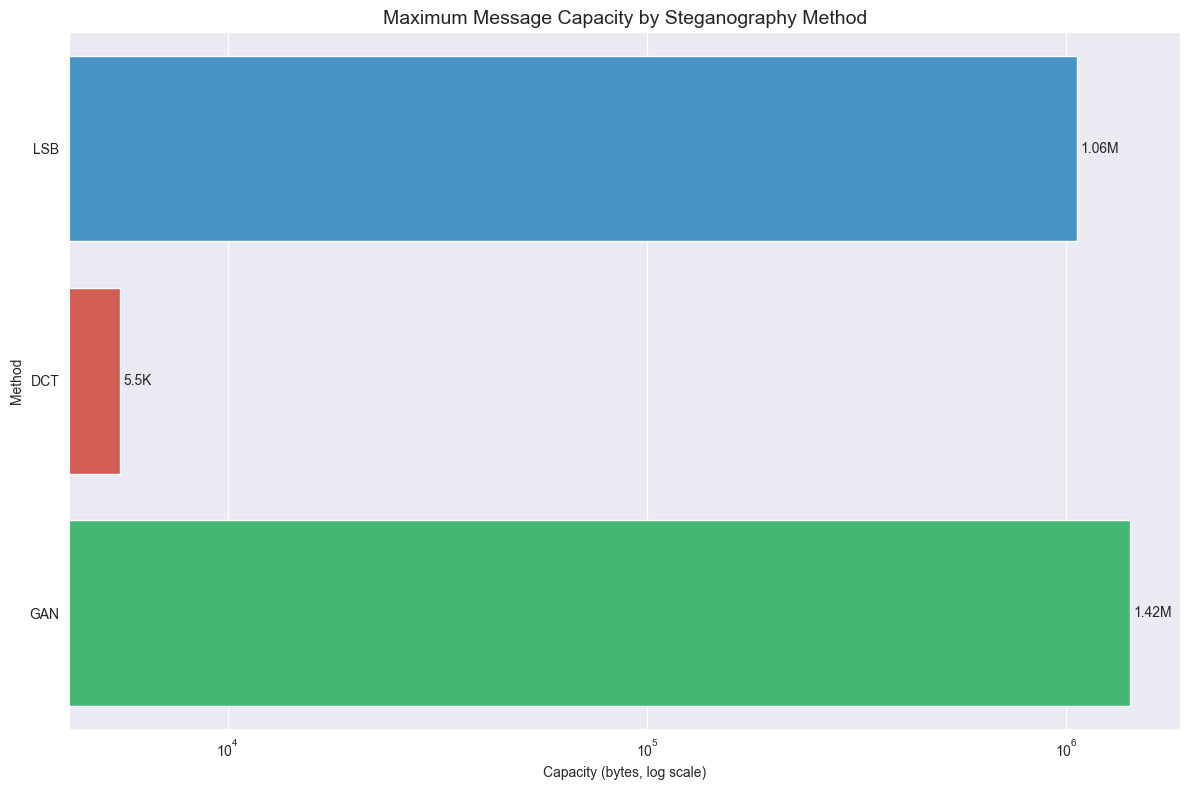

In [18]:
plt.figure(figsize=(12, 8))
# Process data for better labeling
melted = df_results.melt(id_vars='image_name',
                         value_vars=['LSB_max_message_cap', 'DCT_max_message_cap', 'GAN_max_message_cap'],
                         var_name='Method', value_name='Capacity')

# Clean method names
melted['Method'] = melted['Method'].str.replace('_max_message_cap', '')

# Create horizontal bar chart
ax = sns.barplot(x='Capacity', y='Method', data=melted,
                 palette=['#3498db', '#e74c3c', '#2ecc71'],
                 orient='h', errorbar=None)

# Add value labels
for i, p in enumerate(ax.patches):
    width = p.get_width()
    # Format large numbers with K or M suffix
    if width >= 1e6:
        value_text = f"{width/1e6:.2f}M"
    elif width >= 1e3:
        value_text = f"{width/1e3:.1f}K"
    else:
        value_text = f"{width:.0f}"
    ax.text(width + (width*0.02), p.get_y() + p.get_height()/2,
            value_text, ha='left', va='center')

plt.xscale('log')
plt.title('Maximum Message Capacity by Steganography Method', fontsize=14)
plt.xlabel('Capacity (bytes, log scale)')
plt.tight_layout()
plt.show()


In [19]:
# 7. Statistical significance testing
from scipy import stats

print("\nStatistical Significance Tests (p-values):")
# PSNR tests
print("PSNR: LSB vs DCT:", stats.ttest_rel(df_results['LSB_psnr'], df_results['DCT_psnr']).pvalue)
print("PSNR: LSB vs GAN:", stats.ttest_rel(df_results['LSB_psnr'], df_results['GAN_psnr']).pvalue)
print("PSNR: DCT vs GAN:", stats.ttest_rel(df_results['DCT_psnr'], df_results['GAN_psnr']).pvalue)

# SSIM tests
print("\nSSIM: LSB vs DCT:", stats.ttest_rel(df_results['LSB_ssim'], df_results['DCT_ssim']).pvalue)
print("SSIM: LSB vs GAN:", stats.ttest_rel(df_results['LSB_ssim'], df_results['GAN_ssim']).pvalue)
print("SSIM: DCT vs GAN:", stats.ttest_rel(df_results['DCT_ssim'], df_results['GAN_ssim']).pvalue)


Statistical Significance Tests (p-values):
PSNR: LSB vs DCT: 1.7117296463539583e-123
PSNR: LSB vs GAN: 5.387161372157575e-152
PSNR: DCT vs GAN: 0.04790742176741136

SSIM: LSB vs DCT: 3.1833349160208285e-34
SSIM: LSB vs GAN: 2.6589503351069964e-25
SSIM: DCT vs GAN: 4.979864433655534e-06


In [20]:
# 8. Save results to Excel for further analysis
df_results.to_excel("steganography_comparison_results.xlsx", index=False)

In [21]:
summary.to_excel('steganography_comparison_summary.xlsx')

In [22]:
# Test with 3 random strings of specific lengths
# Based on capacity data: small (all succeed), medium (DCT might fail), large (maybe only GAN succeeds)
test_sizes = [3000, 6000, 15000]  # Small, medium, large

# Create temporary output files
temp_lsb = "test_lsb.png"
temp_dct = "test_dct.png"
temp_gan = "test_gan.png"

# Sample image for testing
sample_image_path = os.path.join(image_dir, image_files[0])
sample_image = cv2.imread(sample_image_path)

# Dictionary to store detailed results
detailed_results = []

# Test each size
for size in test_sizes:
    print(f"\n=== Testing with random string of {size} bytes ===")

    # Generate a random string of specified byte length
    try:
        random_string = create_random_string(size)
        print(f"Created random string (showing first 50 chars): {random_string[:50]}...")

        # Test results for this size
        size_result = {'Size (bytes)': size}

        # Test LSB
        try:
            start_time = time.time()
            stego = lsb_tool.encode_message(sample_image_path, temp_lsb, random_string)
            encoding_time = time.time() - start_time

            start_time = time.time()
            decoded = lsb_tool.decode_message(temp_lsb)
            decoding_time = time.time() - start_time

            # Compare as strings
            success = (decoded == random_string)

            # Calculate match percentage
            if decoded:
                common_length = min(len(decoded), len(random_string))
                matches = sum(a == b for a, b in zip(decoded[:common_length], random_string[:common_length]))
                match_percentage = 100 * (matches / len(random_string))
            else:
                match_percentage = 0

            size_result['LSB_success'] = success
            size_result['LSB_match_percentage'] = match_percentage
            size_result['LSB_encoding_time'] = encoding_time
            size_result['LSB_decoding_time'] = decoding_time

            print(f"LSB: {'Success' if success else 'Failed'} - Match: {match_percentage:.2f}% - Encode time: {encoding_time:.3f}s - Decode time: {decoding_time:.3f}s")

        except Exception as e:
            print(f"LSB failed at {size} bytes: {e}")
            size_result['LSB_success'] = False
            size_result['LSB_match_percentage'] = 0
            size_result['LSB_encoding_time'] = None
            size_result['LSB_decoding_time'] = None
        finally:
            if os.path.exists(temp_lsb):
                os.remove(temp_lsb)

        # Test DCT
        try:
            start_time = time.time()
            stego = dct_tool.encode_image(sample_image, random_string)
            encoding_time = time.time() - start_time

            cv2.imwrite(temp_dct, stego)

            start_time = time.time()
            decoded = dct_tool.decode_image(cv2.imread(temp_dct))
            decoding_time = time.time() - start_time

            # Compare (handling potential byte strings)
            if isinstance(decoded, bytes):
                decoded_str = decoded.decode('utf-8', errors='replace')
            else:
                decoded_str = decoded

            success = (decoded_str == random_string)

            # Calculate match percentage
            if decoded_str:
                common_length = min(len(decoded_str), len(random_string))
                matches = sum(a == b for a, b in zip(decoded_str[:common_length], random_string[:common_length]))
                match_percentage = 100 * (matches / len(random_string))
            else:
                match_percentage = 0

            size_result['DCT_success'] = success
            size_result['DCT_match_percentage'] = match_percentage
            size_result['DCT_encoding_time'] = encoding_time
            size_result['DCT_decoding_time'] = decoding_time

            print(f"DCT: {'Success' if success else 'Failed'} - Match: {match_percentage:.2f}% - Encode time: {encoding_time:.3f}s - Decode time: {decoding_time:.3f}s")

        except Exception as e:
            print(f"DCT failed at {size} bytes: {e}")
            size_result['DCT_success'] = False
            size_result['DCT_match_percentage'] = 0
            size_result['DCT_encoding_time'] = None
            size_result['DCT_decoding_time'] = None
        finally:
            if os.path.exists(temp_dct):
                os.remove(temp_dct)

        # Test GAN
        try:
            start_time = time.time()
            steganoGAN.encode(sample_image_path, temp_gan, random_string)
            encoding_time = time.time() - start_time

            start_time = time.time()
            decoded = steganoGAN.decode(temp_gan)
            decoding_time = time.time() - start_time

            # Compare (handling potential byte strings)
            if isinstance(decoded, bytes):
                decoded_str = decoded.decode('utf-8', errors='replace')
            else:
                decoded_str = decoded

            success = (decoded_str == random_string)

            # Calculate match percentage
            if decoded_str:
                common_length = min(len(decoded_str), len(random_string))
                matches = sum(a == b for a, b in zip(decoded_str[:common_length], random_string[:common_length]))
                match_percentage = 100 * (matches / len(random_string))
            else:
                match_percentage = 0

            size_result['GAN_success'] = success
            size_result['GAN_match_percentage'] = match_percentage
            size_result['GAN_encoding_time'] = encoding_time
            size_result['GAN_decoding_time'] = decoding_time

            print(f"GAN: {'Success' if success else 'Failed'} - Match: {match_percentage:.2f}% - Encode time: {encoding_time:.3f}s - Decode time: {decoding_time:.3f}s")

        except Exception as e:
            print(f"GAN failed at {size} bytes: {e}")
            size_result['GAN_success'] = False
            size_result['GAN_match_percentage'] = 0
            size_result['GAN_encoding_time'] = None
            size_result['GAN_decoding_time'] = None
        finally:
            if os.path.exists(temp_gan):
                os.remove(temp_gan)

        detailed_results.append(size_result)

    except Exception as e:
        print(f"Error creating test string of {size} bytes: {e}")

# Convert results to DataFrame
detailed_df = pd.DataFrame(detailed_results)
display(detailed_df)

# Create a summary table showing which methods succeeded at which message sizes
success_matrix = pd.DataFrame({
    'Size (bytes)': detailed_df['Size (bytes)'],
    'LSB': detailed_df['LSB_success'].map({True: 'Success', False: 'Fail'}),
    'DCT': detailed_df['DCT_success'].map({True: 'Success', False: 'Fail'}),
    'GAN': detailed_df['GAN_success'].map({True: 'Success', False: 'Fail'})
})
display(success_matrix)


=== Testing with random string of 3000 bytes ===
Created random string (showing first 50 chars): mDzabUc7u84cCd62k5nXgly8u7U7HUQlJ6WiKv4u84z0bjOYVN...
LSB: Success - Match: 100.00% - Encode time: 1.701s - Decode time: 4.107s
DCT: Failed - Match: 0.00% - Encode time: 1.172s - Decode time: 0.492s
GAN: Success - Match: 100.00% - Encode time: 9.947s - Decode time: 56.920s

=== Testing with random string of 6000 bytes ===
Created random string (showing first 50 chars): qn8LPOOsRfFhrVFHt8Ume8dGyaqsbb6SK5hBiQGUQ7jdNykVf6...
LSB: Success - Match: 100.00% - Encode time: 1.802s - Decode time: 3.708s
DCT: Failed - Match: 0.00% - Encode time: 1.293s - Decode time: 0.528s
GAN failed at 6000 bytes: Failed to find message.

=== Testing with random string of 15000 bytes ===
Created random string (showing first 50 chars): WpDmPJCCSEeLAKxdaK0i07MTexX0COzVx9WHdD8MFGhx8wFVZb...
LSB: Success - Match: 100.00% - Encode time: 1.908s - Decode time: 3.814s
DCT: Failed - Match: 0.00% - Encode time: 1.323s - Dec

,Size (bytes),LSB_success,LSB_match_percentage,LSB_encoding_time,LSB_decoding_time,DCT_success,DCT_match_percentage,DCT_encoding_time,DCT_decoding_time,GAN_success,GAN_match_percentage,GAN_encoding_time,GAN_decoding_time
0,3000,True,100.0,1.701151,4.106825,False,0,1.171906,0.492446,True,100.0,9.947027,56.919629
1,6000,True,100.0,1.801661,3.707867,False,0,1.292875,0.527537,False,0.0,NaN,NaN
2,15000,True,100.0,1.907596,3.813887,False,0,1.322792,0.550120,False,0.0,NaN,NaN


,Size (bytes),LSB,DCT,GAN
0,3000,Success,Fail,Success
1,6000,Success,Fail,Fail
2,15000,Success,Fail,Fail


In [24]:
detailed_df.to_excel('detailed_capability.xlsx')
success_matrix.to_excel('success_capability.xlsx')

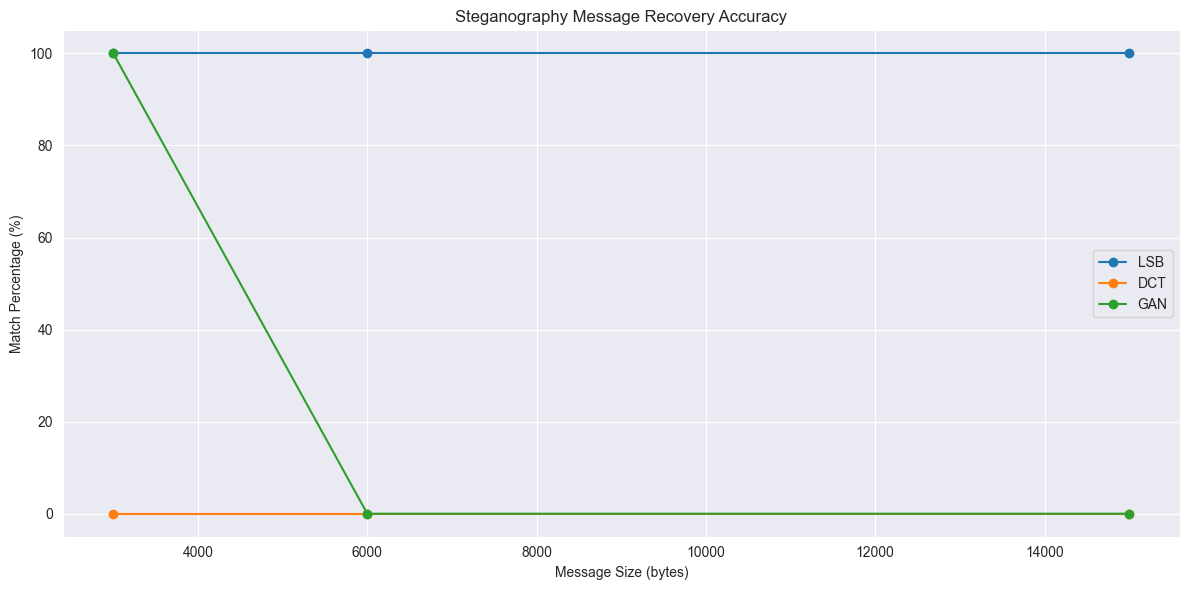

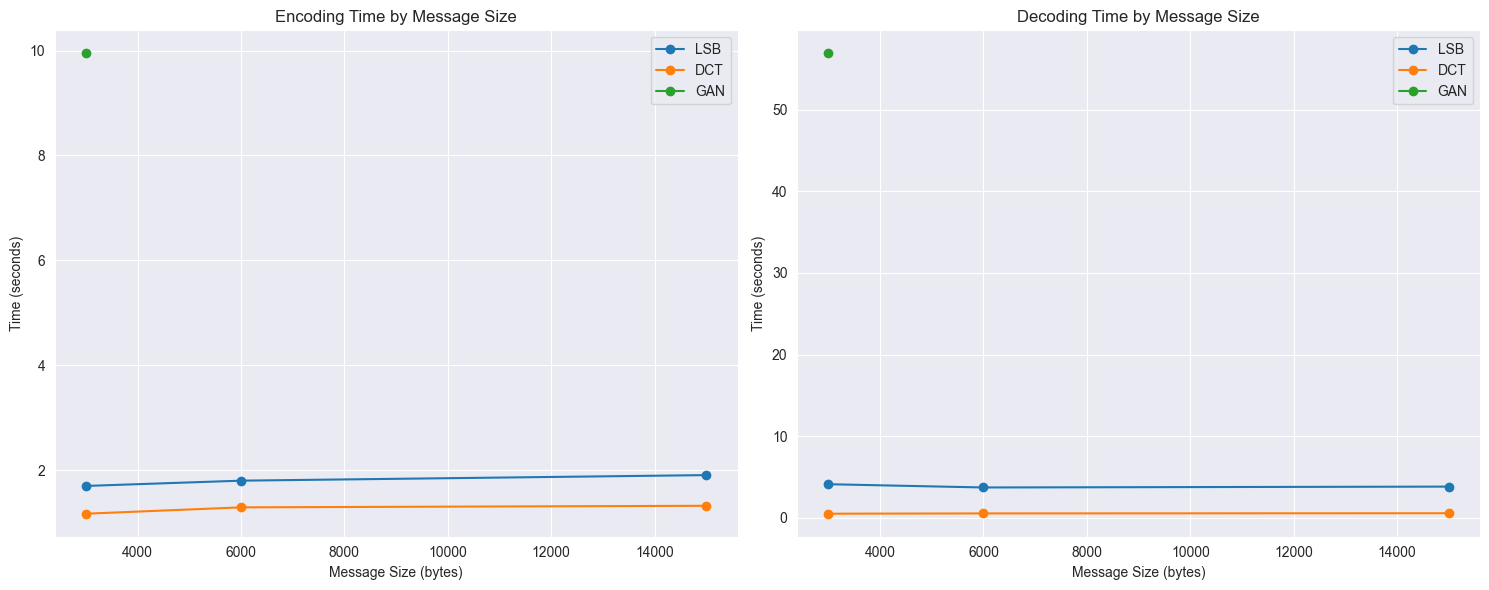


=== SUMMARY OF MESSAGE SIZE LIMITS ===
LSB succeeded with all tested message sizes up to 15000 bytes
DCT fails at message size: 3000 bytes
GAN fails at message size: 6000 bytes


In [23]:
# Visualize the match percentages
plt.figure(figsize=(12, 6))
for method in ['LSB', 'DCT', 'GAN']:
    plt.plot(detailed_df['Size (bytes)'], detailed_df[f'{method}_match_percentage'], 'o-', label=method)
plt.xlabel('Message Size (bytes)')
plt.ylabel('Match Percentage (%)')
plt.title('Steganography Message Recovery Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Visualize the encoding and decoding times
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
for method in ['LSB', 'DCT', 'GAN']:
    plt.plot(detailed_df['Size (bytes)'], detailed_df[f'{method}_encoding_time'], 'o-', label=method)
plt.xlabel('Message Size (bytes)')
plt.ylabel('Time (seconds)')
plt.title('Encoding Time by Message Size')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
for method in ['LSB', 'DCT', 'GAN']:
    plt.plot(detailed_df['Size (bytes)'], detailed_df[f'{method}_decoding_time'], 'o-', label=method)
plt.xlabel('Message Size (bytes)')
plt.ylabel('Time (seconds)')
plt.title('Decoding Time by Message Size')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Print a clear summary of which methods failed at which message sizes
print("\n=== SUMMARY OF MESSAGE SIZE LIMITS ===")
for method in ['LSB', 'DCT', 'GAN']:
    if False in detailed_df[f'{method}_success'].values:
        fail_size = detailed_df[detailed_df[f'{method}_success'] == False]['Size (bytes)'].min()
        print(f"{method} fails at message size: {fail_size} bytes")
    else:
        print(f"{method} succeeded with all tested message sizes up to {detailed_df['Size (bytes)'].max()} bytes")